# initial analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition
)
import scanpy as sc
import numpy as np
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse

def volcano_from_adata(
    adata,
    groupby="treatment",
    group="PBS",
    reference="WT",
    layer="counts",
    method="wilcoxon",
    lfc_thr=1.0,
    padj_thr=0.05,
    lfc_max=5,
    top_labels=10,
    title=None,
    figsize=(7,5)
):
    """
    Run DE between two groups in AnnData and plot a volcano.
    """

    # --- Run DE ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        groups=[group],
        reference=reference,
        method=method,
        layer=layer,
        use_raw=False
    )
    de = sc.get.rank_genes_groups_df(adata, group=group)

    # --- Filter extreme LFCs ---
    de = de[np.isfinite(de["logfoldchanges"])]
    de = de[(de["logfoldchanges"] < lfc_max) & (de["logfoldchanges"] > -lfc_max)]

    # --- Fallback: compute log2FC manually if needed ---
    if de["logfoldchanges"].isna().all() or np.isfinite(de["logfoldchanges"]).sum() == 0:
        X = adata.layers.get(layer, adata.X)
        if sparse.issparse(X):
            X = X.toarray()
        mask_g = adata.obs[groupby].values == group
        mask_r = adata.obs[groupby].values == reference
        eps = 1e-9
        mean_g = X[mask_g].mean(axis=0)
        mean_r = X[mask_r].mean(axis=0)
        log2fc = np.log2((mean_g + eps) / (mean_r + eps))
        lfc_s = pd.Series(log2fc, index=adata.var_names, name="log2fc_manual")
        de = de.merge(lfc_s, left_on="names", right_index=True, how="left")
        de["log2fc_use"] = de["log2fc_manual"]
    else:
        de["log2fc_use"] = de["logfoldchanges"]

    # --- Volcano columns ---
    de["padj"] = de["pvals_adj"].fillna(de["pvals"])
    de["neglog10_padj"] = -np.log10(np.clip(de["padj"].values, 1e-300, 1.0))
    de["sig"] = np.where(
        (de["padj"] < padj_thr) & (de["log2fc_use"].abs() > lfc_thr),
        "significant", "ns"
    )

    # --- Plot ---
    plt.figure(figsize=figsize)
    plt.scatter(
        de.loc[de["sig"]=="ns", "log2fc_use"],
        de.loc[de["sig"]=="ns", "neglog10_padj"],
        s=8, alpha=0.5, color="gray"
    )
    plt.scatter(
        de.loc[de["sig"]=="significant", "log2fc_use"],
        de.loc[de["sig"]=="significant", "neglog10_padj"],
        s=10, alpha=0.8, color="red"
    )
    plt.axvline(+lfc_thr, linestyle="--", linewidth=1)
    plt.axvline(-lfc_thr, linestyle="--", linewidth=1)
    plt.axhline(-np.log10(padj_thr), linestyle="--", linewidth=1)
    plt.xlabel(f"log2 fold change ({group} vs {reference})")
    plt.ylabel("-log10(FDR)")
    if title:
        plt.title(title)

    # --- Annotate top genes ---
    def label_top(df, side="right", k=10):
        if side == "right":
            sub = df[(df["sig"]=="significant") & (df["log2fc_use"]>0)]
            sub = sub.sort_values(
                ["neglog10_padj","log2fc_use"], ascending=False
            ).head(k)
        else:
            sub = df[(df["sig"]=="significant") & (df["log2fc_use"]<0)]
            sub = sub.sort_values(
                ["neglog10_padj","log2fc_use"], ascending=[False, True]
            ).head(k)
        for _, r in sub.iterrows():
            plt.text(r["log2fc_use"], r["neglog10_padj"], r["names"], fontsize=8)

    label_top(de, "right", k=top_labels)
    label_top(de, "left",  k=top_labels)

    plt.tight_layout()
    plt.show()

    return de
def compute_brichos_rescue(
    de_table_PBS_WT,         # PBS vs WT
    de_table_BRICHOS_WT,     # BRICHOS vs WT
    de_table_BRICHOS_PBS,    # BRICHOS vs PBS
    lfc_thr_up=1.0,          # PBS up threshold (log2FC)
    padj_thr=0.05,           # FDR threshold
    min_delta_vs_WT=0.5,     # minimum attenuation vs WT to call (PBS-WT) - (BRICHOS-WT)
    b_vs_pbs_neg=-0.5,       # BRICHOS vs PBS should be < this (down vs PBS)
    require_b_vs_pbs_sig=True
):
    # index by gene
    pbs = de_table_PBS_WT.set_index("names")[["log2fc_use","padj"]].rename(
        columns={"log2fc_use":"lfc_pbs_wt","padj":"padj_pbs_wt"}
    )
    br_wt = de_table_BRICHOS_WT.set_index("names")[["log2fc_use","padj"]].rename(
        columns={"log2fc_use":"lfc_b_wt","padj":"padj_b_wt"}
    )
    br_pbs = de_table_BRICHOS_PBS.set_index("names")[["log2fc_use","padj"]].rename(
        columns={"log2fc_use":"lfc_b_pbs","padj":"padj_b_pbs"}
    )

    # merge
    df = pbs.join(br_wt, how="inner").join(br_pbs, how="inner")

    # start from disease-up genes
    df = df[(df["lfc_pbs_wt"] > lfc_thr_up) & (df["padj_pbs_wt"] < padj_thr)].copy()

    # rescue score: attenuation vs WT
    df["delta_vs_WT"] = df["lfc_pbs_wt"] - df["lfc_b_wt"]

    # classification
    cond_strict = (
        (df["delta_vs_WT"] >= min_delta_vs_WT) &
        (df["lfc_b_pbs"] <= b_vs_pbs_neg) &
        ((df["padj_b_pbs"] < padj_thr) if require_b_vs_pbs_sig else True)
    )

    cond_partial = (
        (df["delta_vs_WT"] >= min_delta_vs_WT) &
        ~cond_strict
    )

    df["rescue_class"] = np.where(cond_strict, "rescued",
                           np.where(cond_partial, "partial_rescue", "not_rescued"))

    # sort by strongest attenuation
    df_sorted = df.sort_values(["rescue_class","delta_vs_WT"], ascending=[True, False])

    # summaries
    n_all = df.shape[0]
    n_rescued = (df["rescue_class"]=="rescued").sum()
    n_partial = (df["rescue_class"]=="partial_rescue").sum()
    n_not = (df["rescue_class"]=="not_rescued").sum()

    print(f"Disease-up genes (PBS vs WT): {n_all}")
    print(f"Rescued (strict): {n_rescued}")
    print(f"Partial rescue: {n_partial}")
    print(f"Not rescued: {n_not}")

    # convenient views
    rescued_tbl = df[df["rescue_class"]=="rescued"].sort_values("delta_vs_WT", ascending=False)
    partial_tbl = df[df["rescue_class"]=="partial_rescue"].sort_values("delta_vs_WT", ascending=False)
    top_any    = df.sort_values("delta_vs_WT", ascending=False)

    return df_sorted.reset_index().rename(columns={"index":"gene"}), rescued_tbl.reset_index().rename(columns={"index":"gene"}), partial_tbl.reset_index().rename(columns={"index":"gene"}), top_any.reset_index().rename(columns={"index":"gene"})

import scanpy as sc
import matplotlib.pyplot as plt
plaque_induced_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2", "Cst7",
    "Fcer1g", "Axl", "Lilrb4", "Lpl", "Csf1", "Csf1r", "Cst3", "Ctsb", "Gpnmb", "Hexb",
    "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]
olig_genes = [
    "Plp1", "Mbp", "Mobp", "Cnp", "Cldn11", "Mal", "Apod", "Trf", "Fth1", "Plekhb1", "Ppp1r14a", "Ttyh2", "Fa2h", "Aspa"
]

In [2]:
ad = sc.read_h5ad('../data/ST_BRICHOS_new.h5ad')

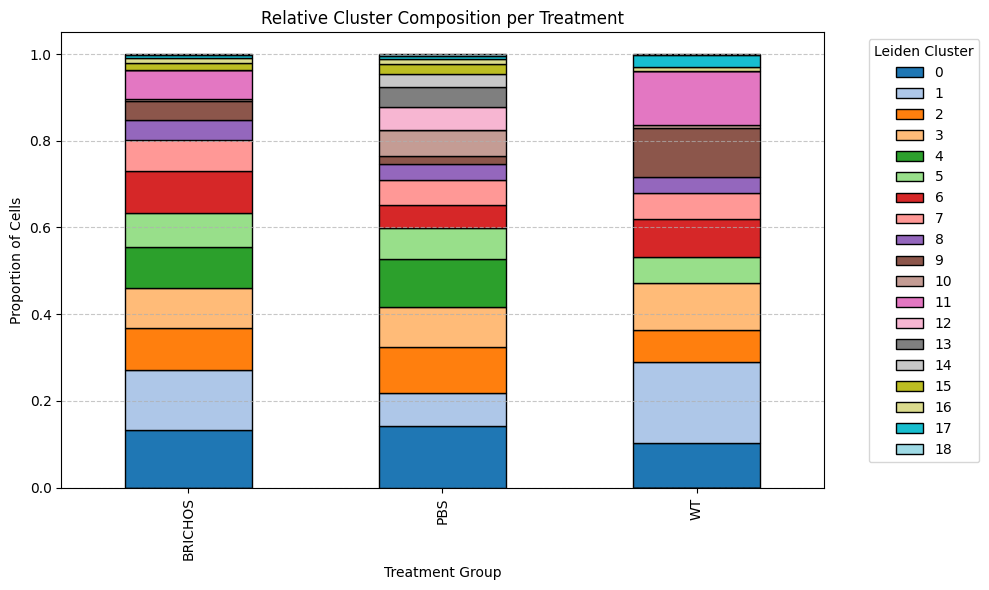

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute relative distribution
cluster_distribution = pd.crosstab(ad.obs["treatment"], ad.obs["leiden"])
relative_distribution = cluster_distribution.div(cluster_distribution.sum(axis=1), axis=0)

# Plot
ax = relative_distribution.plot(
    kind="bar", 
    stacked=True, 
    figsize=(10, 6), 
    colormap="tab20",  # Or try "viridis", "Set3", etc.
    edgecolor="black"
)

plt.title("Relative Cluster Composition per Treatment")
plt.ylabel("Proportion of Cells")
plt.xlabel("Treatment Group")
plt.legend(title="Leiden Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

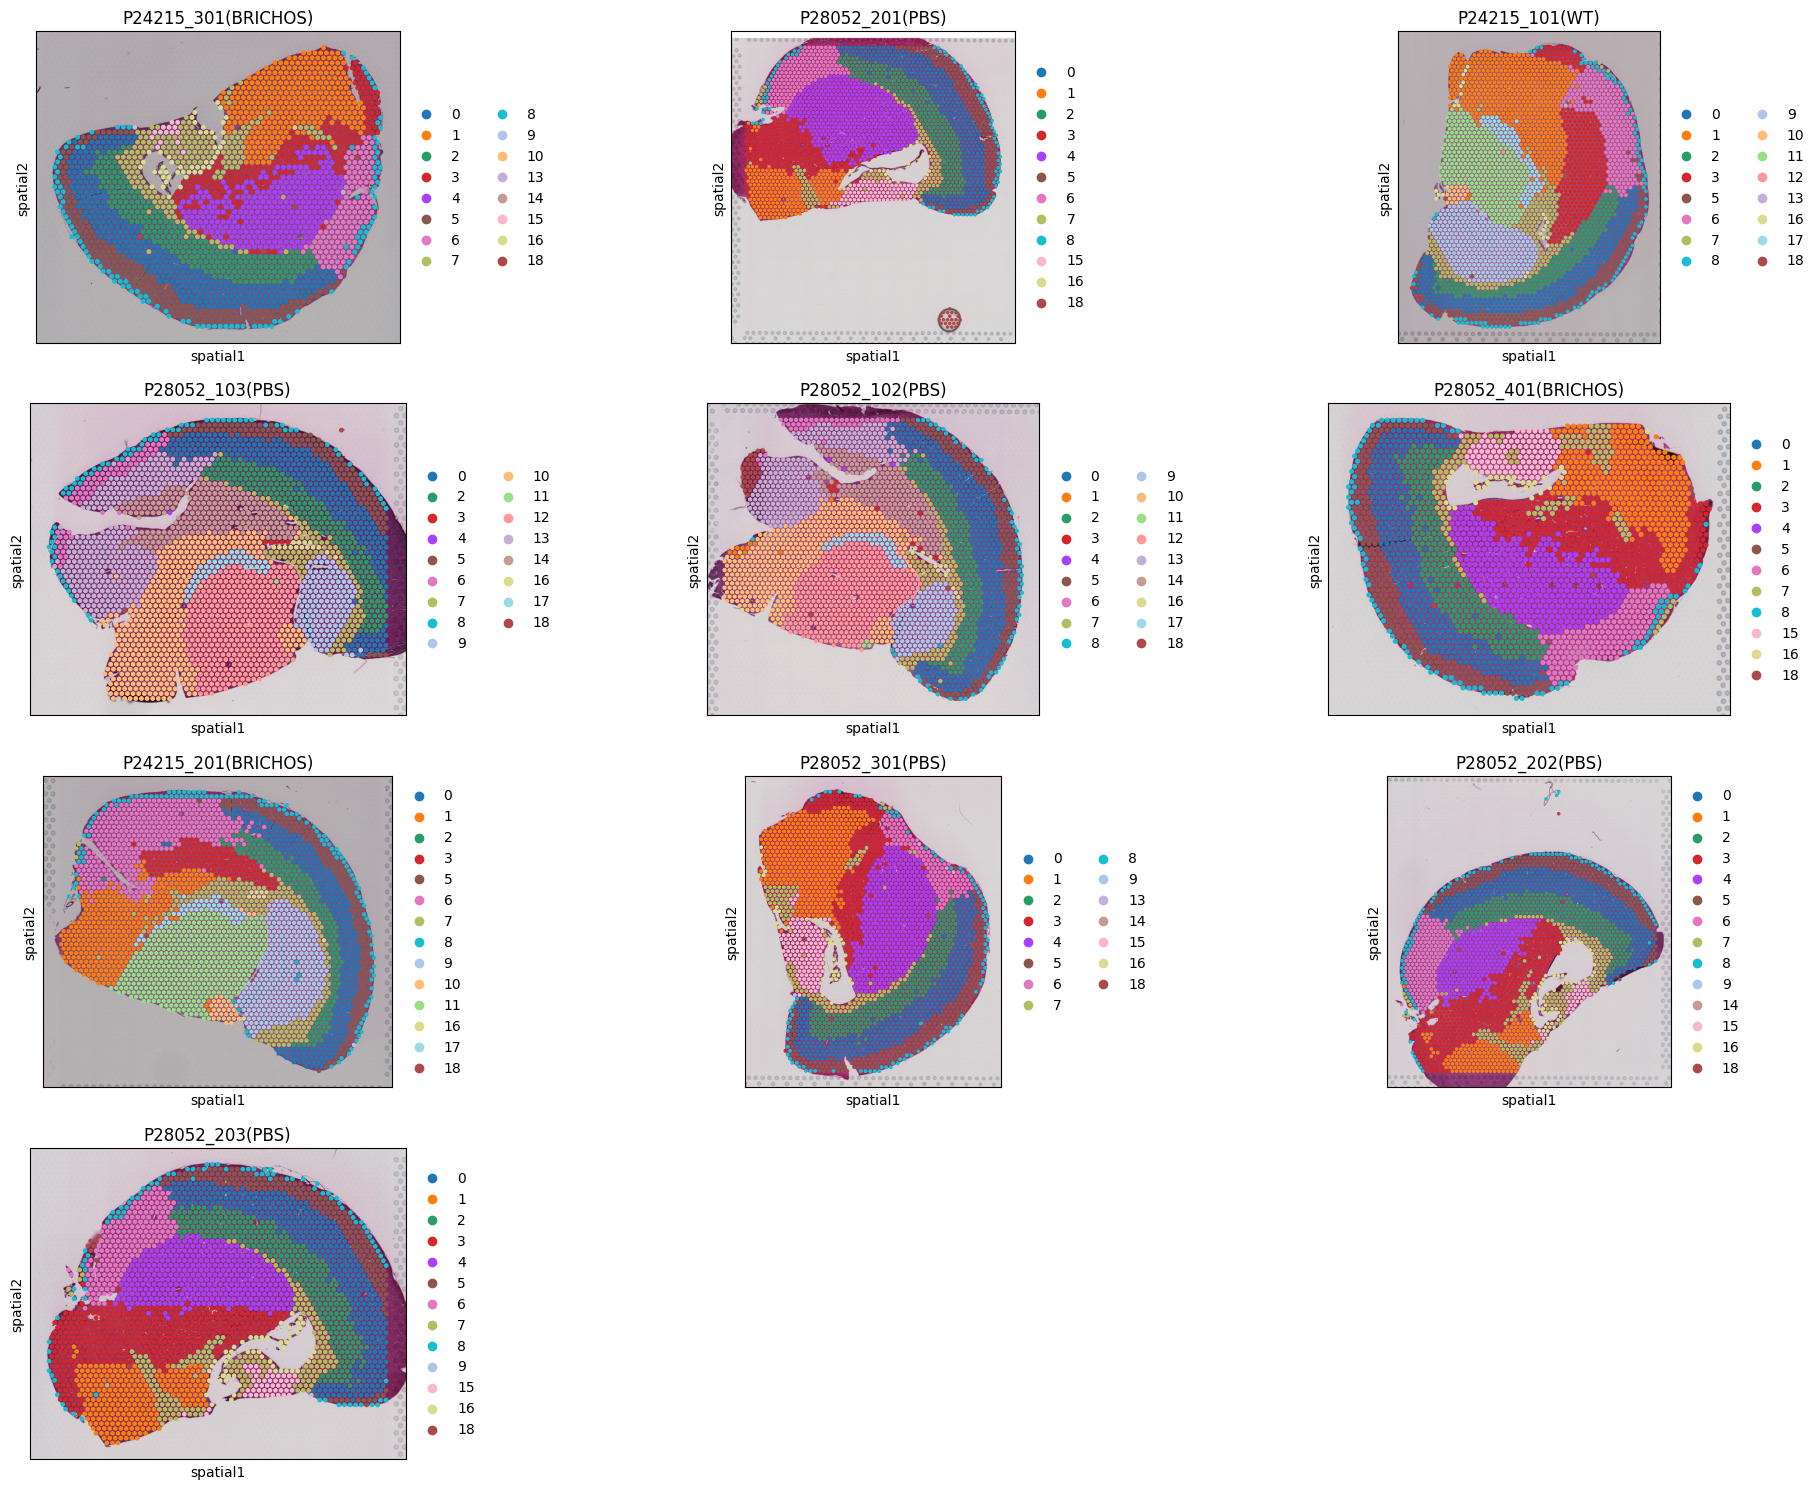

In [4]:
plot_spatial_clusters_per_sample(ad, color = 'leiden', figsize=(20,15))

In [5]:
sc.tl.rank_genes_groups(ad, groupby='leiden', method='wilcoxon')

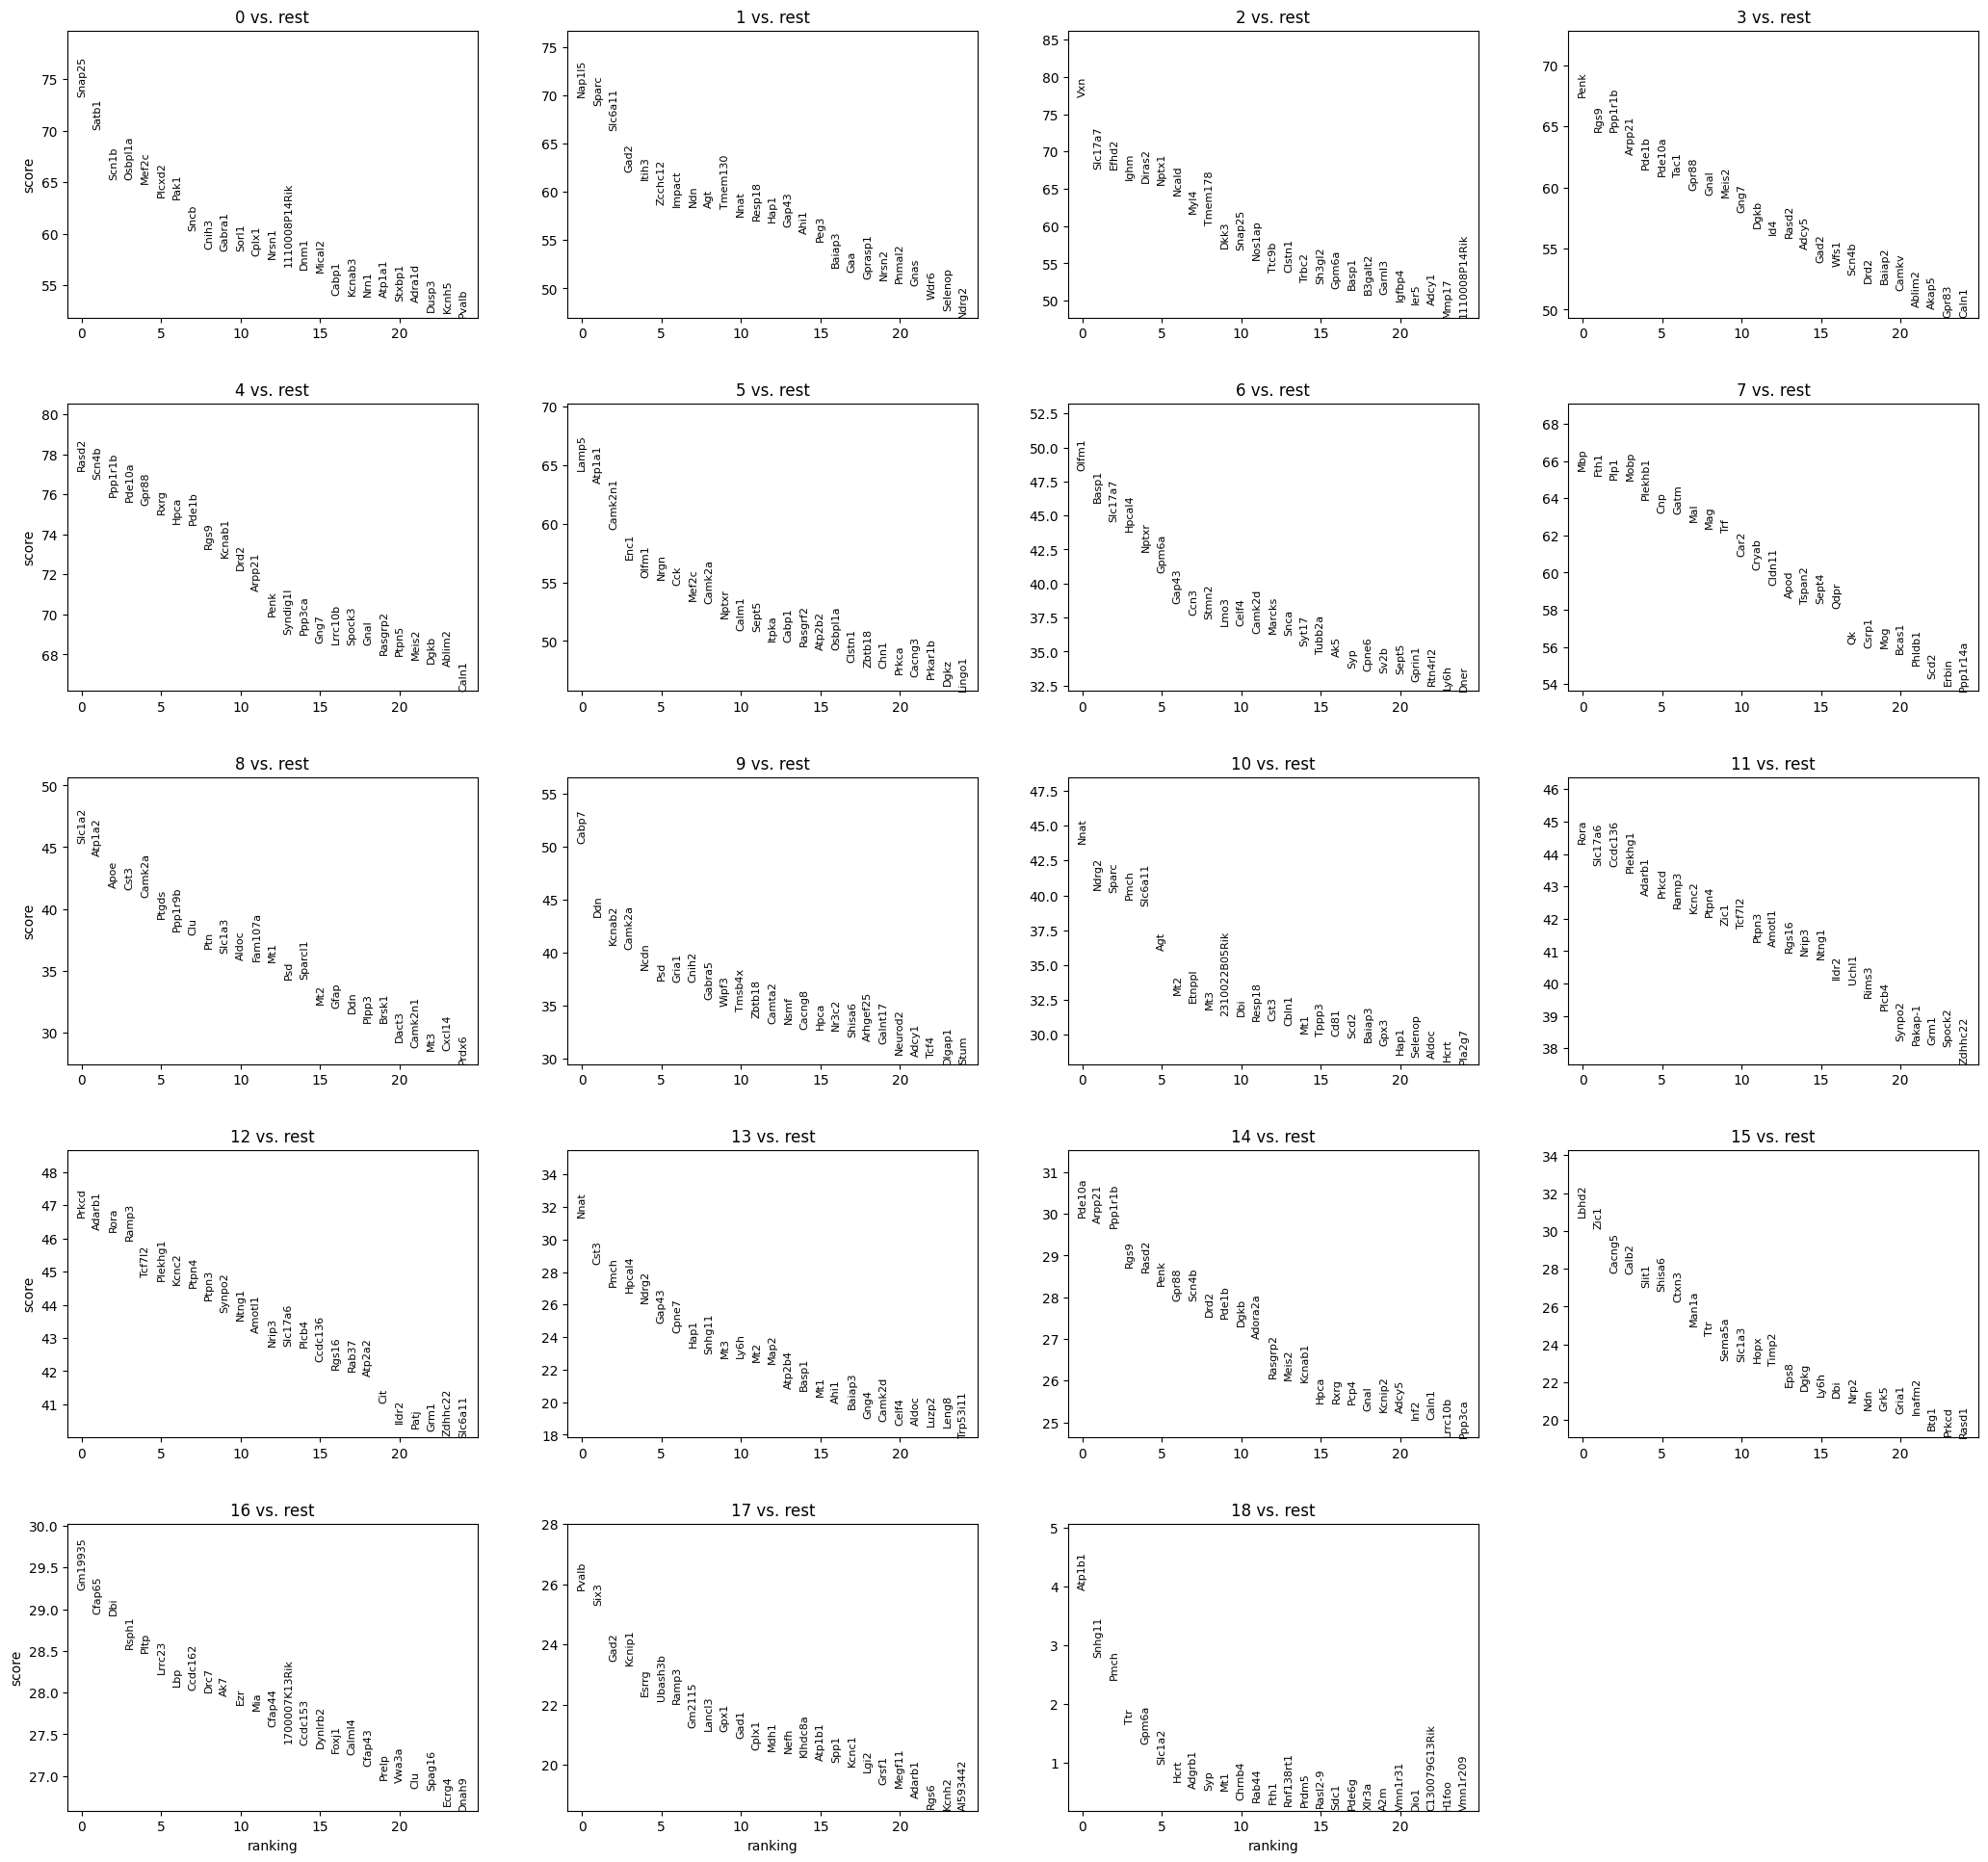

In [6]:
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(ad, n_genes=25, sharey=False)

In [7]:
sc.tl.rank_genes_groups(ad, groupby='treatment', method='wilcoxon')

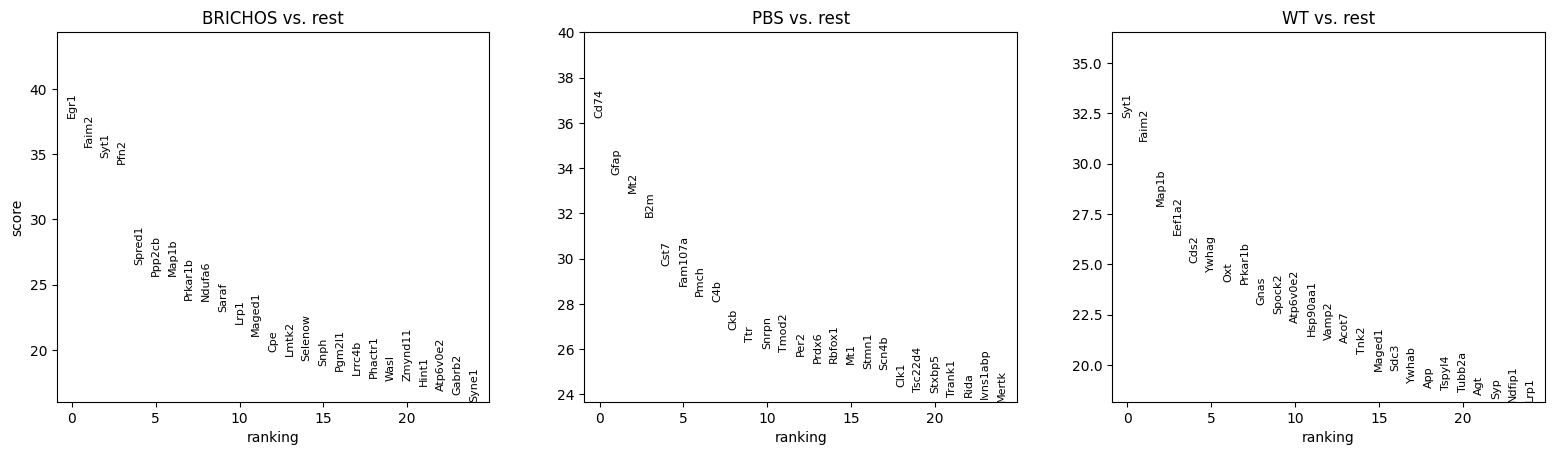

In [8]:
# See top 5 marker genes per cluster
sc.pl.rank_genes_groups(ad, n_genes=25, sharey=False)

# Plaque-Induced Gene Expression by Treatment Group

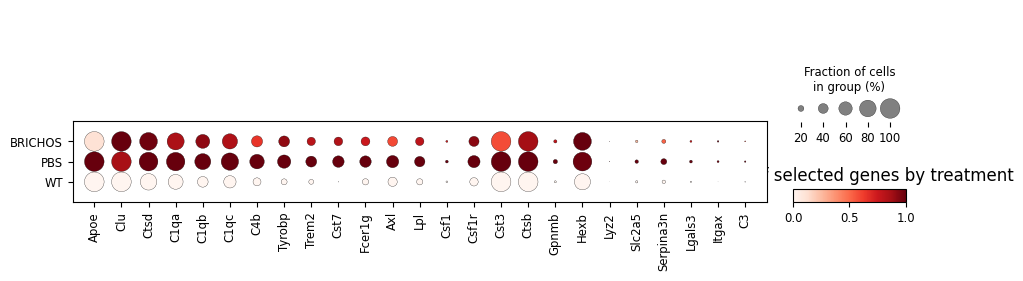

In [23]:
plaque_induced_genes = [
    "Apoe", "Clu", "Ctsd", "C1qa", "C1qb", "C1qc", "C4b", "Tyrobp", "Trem2",
    "Cst7", "Fcer1g", "Axl", "Lpl", "Csf1", "Csf1r", "Cst3",
    "Ctsb", "Gpnmb", "Hexb", "Lyz2", "Slc2a5", "Serpina3n", "Lgals3", "Itgax", "C3"
]

plot_dotplot_by_treatment(ad, genes=plaque_induced_genes)

In [24]:
sc.tl.score_genes(ad, gene_list=plaque_induced_genes, score_name='plaque_score')
sc.tl.score_genes(ad, gene_list=olig_genes, score_name='olig_score')

In [25]:
from scipy.stats import mannwhitneyu

group1 = ad.obs[ad.obs["treatment"] == "PBS"]["plaque_score"].dropna()
group2 = ad.obs[ad.obs["treatment"] == "WT"]["plaque_score"].dropna()

stat, pval = mannwhitneyu(group1, group2)
print(f"📊 Mann–Whitney U test p-value: {pval:.4e}")

📊 Mann–Whitney U test p-value: 0.0000e+00


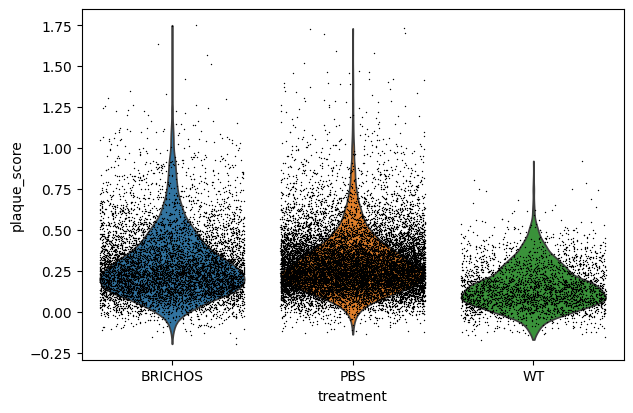

In [26]:
# Plot module score by treatment group
sc.pl.violin(ad, keys="plaque_score", groupby="treatment", stripplot=True, jitter=0.4)


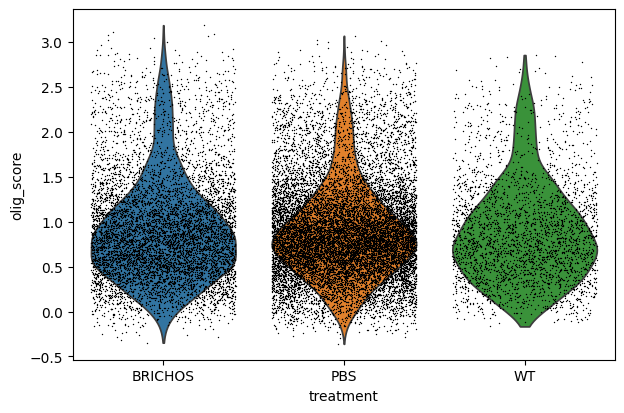

In [27]:
# Plot module score by treatment group
sc.pl.violin(ad, keys="olig_score", groupby="treatment", stripplot=True, jitter=0.4)


# 1. Baseline Gene Expression Analysis
Comparison of wild-type (WT) mice and APPNLGF non-treated mice to identify genes that are differentially expressed globally and in specific anatomical regions of the brain.  

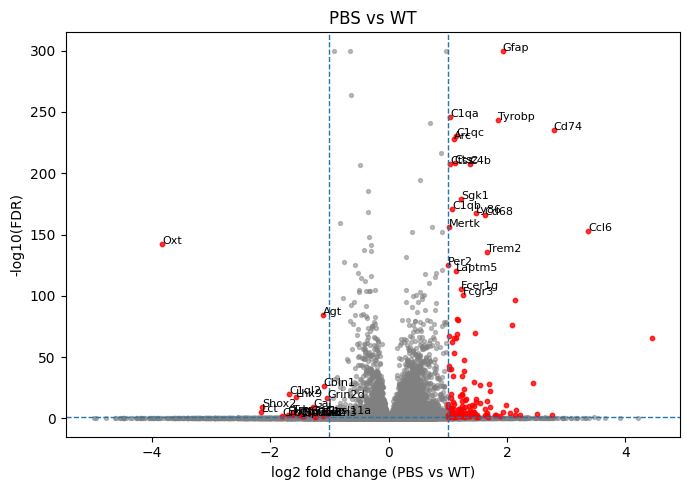

,names,scores,logfoldchanges,pvals,pvals_adj,log2fc_use,padj,neglog10_padj,sig
0,Gfap,54.275009,1.930943,0.000000,0.000000,1.93,0.00e+00,300.00,significant
2,B2m,39.198086,0.963690,0.000000,0.000000,0.96,0.00e+00,300.00,ns
3,C1qa,33.788212,1.041871,0.000000,0.000000,1.04,7.87e-247,246.10,significant
4,Tyrobp,33.592270,1.843857,0.000000,0.000000,1.84,5.10e-244,243.29,significant
5,Mt2,33.445057,0.695283,0.000000,0.000000,0.70,6.33e-242,241.20,ns
6,Cd74,33.005737,2.792581,0.000000,0.000000,2.79,1.26e-235,234.90,significant
7,C1qc,32.689919,1.137827,0.000000,0.000000,1.14,3.70e-231,230.43,significant
8,Arc,32.506016,1.100154,0.000000,0.000000,1.10,1.37e-228,227.86,significant
9,Hexb,31.682011,0.893799,0.000000,0.000000,0.89,3.97e-217,216.40,ns
10,Ctsz,31.065619,1.118659,0.000000,0.000000,1.12,9.40e-209,208.03,significant


In [37]:
# Subset WT vs PBS
ad_base = ad[ad.obs["treatment"].isin(["WT", "PBS"])].copy()
ad_base.obs["treatment"] = ad_base.obs["treatment"].astype("category")

# Volcano
de_table_PBS_WT = volcano_from_adata(
    ad_base,
    groupby="treatment",
    group="PBS",
    reference="WT",
    layer=None,
    method="wilcoxon",
    lfc_thr=1.0,
    padj_thr=0.05,
    lfc_max=5,
    top_labels=20,
    title="PBS vs WT"
)

# Inspect DE table
de_table_PBS_WT.head(30).style.background_gradient(
    subset=["log2fc_use", "neglog10_padj"],
    cmap="coolwarm"
).format({
    "log2fc_use": "{:.2f}",
    "padj": "{:.2e}",
    "neglog10_padj": "{:.2f}"
})

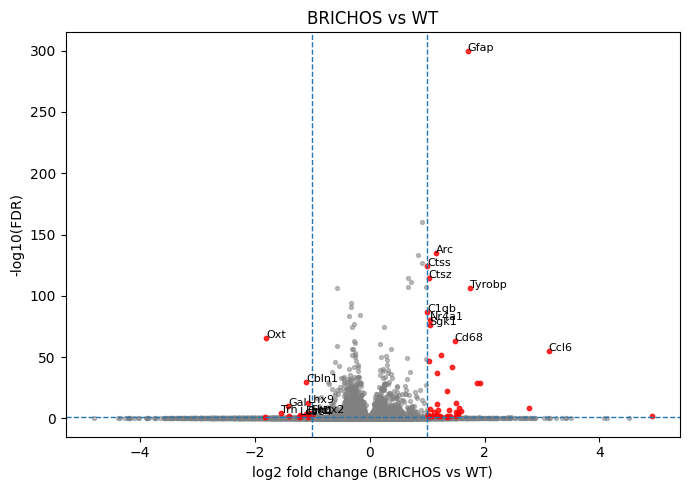

,names,scores,logfoldchanges,pvals,pvals_adj,log2fc_use,padj,neglog10_padj,sig
0,Gfap,42.556038,1.704950,0.000000,0.000000,1.70,0.00e+00,300.00,significant
1,Hexb,27.362019,0.904706,0.000000,0.000000,0.90,7.28e-161,160.14,ns
3,Arc,25.125528,1.151432,0.000000,0.000000,1.15,1.23e-135,134.91,significant
4,Egr1,25.004681,0.845624,0.000000,0.000000,0.85,2.04e-134,133.69,ns
5,C1qa,24.374250,0.904064,0.000000,0.000000,0.90,1.00e-127,127.00,ns
6,Ctss,24.120678,1.001998,0.000000,0.000000,1.00,4.06e-125,124.39,significant
7,Ctsz,23.185421,1.027936,0.000000,0.000000,1.03,1.50e-115,114.82,significant
8,B2m,23.131216,0.664767,0.000000,0.000000,0.66,4.68e-115,114.33,ns
9,Ctsd,22.830399,0.723696,0.000000,0.000000,0.72,4.29e-112,111.37,ns
10,Ndn,22.390547,0.672846,0.000000,0.000000,0.67,8.29e-108,107.08,ns


In [29]:
# Subset WT vs BRICHOS
ad_base = ad[ad.obs["treatment"].isin(["WT", "BRICHOS"])].copy()
ad_base.obs["treatment"] = ad_base.obs["treatment"].astype("category")

# Volcano
de_table_BRICHOS_WT = volcano_from_adata(
    ad_base,
    groupby="treatment",
    group="BRICHOS",
    reference="WT",
    layer=None,
    method="wilcoxon",
    lfc_thr=1.0,
    padj_thr=0.05,
    lfc_max=5,
    top_labels=10,
    title="BRICHOS vs WT"
)

# Inspect DE table
de_table_BRICHOS_WT.head(30).style.background_gradient(
    subset=["log2fc_use", "neglog10_padj"],
    cmap="coolwarm"
).format({
    "log2fc_use": "{:.2f}",
    "padj": "{:.2e}",
    "neglog10_padj": "{:.2f}"
})

# 2. Validation of AD-Related Genes 
Cross-referencing the identified differentially expressed genes in APPNLGF non-treated mice with published datasets on APP mouse models to determine which of these genes are directly associated with AD pathology.  

In [38]:
# Check if DE genes overlap
de_table_PBS_WT["is_ad_related"] = de_table_PBS_WT["names"].isin(plaque_induced_genes)
# Inspect DE table
de_table_PBS_WT.head(30).style.background_gradient(
    subset=["log2fc_use", "neglog10_padj"],
    cmap="coolwarm"
).format({
    "log2fc_use": "{:.2f}",
    "padj": "{:.2e}",
    "neglog10_padj": "{:.2f}"
})

,names,scores,logfoldchanges,pvals,pvals_adj,log2fc_use,padj,neglog10_padj,sig,is_ad_related
0,Gfap,54.275009,1.930943,0.000000,0.000000,1.93,0.00e+00,300.00,significant,False
2,B2m,39.198086,0.963690,0.000000,0.000000,0.96,0.00e+00,300.00,ns,False
3,C1qa,33.788212,1.041871,0.000000,0.000000,1.04,7.87e-247,246.10,significant,True
4,Tyrobp,33.592270,1.843857,0.000000,0.000000,1.84,5.10e-244,243.29,significant,True
5,Mt2,33.445057,0.695283,0.000000,0.000000,0.70,6.33e-242,241.20,ns,False
6,Cd74,33.005737,2.792581,0.000000,0.000000,2.79,1.26e-235,234.90,significant,False
7,C1qc,32.689919,1.137827,0.000000,0.000000,1.14,3.70e-231,230.43,significant,True
8,Arc,32.506016,1.100154,0.000000,0.000000,1.10,1.37e-228,227.86,significant,False
9,Hexb,31.682011,0.893799,0.000000,0.000000,0.89,3.97e-217,216.40,ns,True
10,Ctsz,31.065619,1.118659,0.000000,0.000000,1.12,9.40e-209,208.03,significant,False


In [39]:
# Check if DE genes overlap
de_table_BRICHOS_WT["is_ad_related"] = de_table_BRICHOS_WT["names"].isin(plaque_induced_genes)
# Inspect DE table
de_table_BRICHOS_WT.head(30).style.background_gradient(
    subset=["log2fc_use", "neglog10_padj"],
    cmap="coolwarm"
).format({
    "log2fc_use": "{:.2f}",
    "padj": "{:.2e}",
    "neglog10_padj": "{:.2f}"
})

,names,scores,logfoldchanges,pvals,pvals_adj,log2fc_use,padj,neglog10_padj,sig,is_ad_related
0,Gfap,42.556038,1.704950,0.000000,0.000000,1.70,0.00e+00,300.00,significant,False
1,Hexb,27.362019,0.904706,0.000000,0.000000,0.90,7.28e-161,160.14,ns,True
3,Arc,25.125528,1.151432,0.000000,0.000000,1.15,1.23e-135,134.91,significant,False
4,Egr1,25.004681,0.845624,0.000000,0.000000,0.85,2.04e-134,133.69,ns,False
5,C1qa,24.374250,0.904064,0.000000,0.000000,0.90,1.00e-127,127.00,ns,True
6,Ctss,24.120678,1.001998,0.000000,0.000000,1.00,4.06e-125,124.39,significant,False
7,Ctsz,23.185421,1.027936,0.000000,0.000000,1.03,1.50e-115,114.82,significant,False
8,B2m,23.131216,0.664767,0.000000,0.000000,0.66,4.68e-115,114.33,ns,False
9,Ctsd,22.830399,0.723696,0.000000,0.000000,0.72,4.29e-112,111.37,ns,True
10,Ndn,22.390547,0.672846,0.000000,0.000000,0.67,8.29e-108,107.08,ns,False


# 3. BRICHOS Treatment Effect
Comparison of APP non-treated mice and APP BRICHOS-treated mice to identify genes modulated by BRICHOS treatment, both globally and within distinct brain regions.  

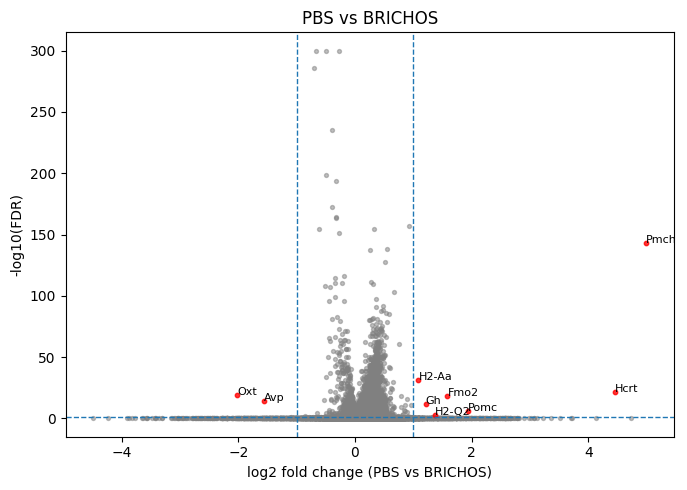

,names,scores,logfoldchanges,pvals,pvals_adj,log2fc_use,padj,neglog10_padj,sig
0,Cd74,27.039452,0.931137,0.000000,0.000000,0.93,8.66e-158,157.06,ns
1,Cox6c,26.831060,0.327601,0.000000,0.000000,0.33,2.19e-155,154.66,ns
2,Pmch,25.812761,4.993712,0.000000,0.000000,4.99,7.97e-144,143.10,significant
3,Ttr,25.356169,0.555905,0.000000,0.000000,0.56,9.00e-139,138.05,ns
4,Ckb,25.317446,0.264556,0.000000,0.000000,0.26,2.26e-138,137.65,ns
5,Stmn1,24.359552,0.518006,0.000000,0.000000,0.52,4.78e-128,127.32,ns
6,Tmod2,22.797920,0.277731,0.000000,0.000000,0.28,4.29e-112,111.37,ns
7,Mt2,22.605862,0.317075,0.000000,0.000000,0.32,2.97e-110,109.53,ns
8,Snrpn,21.939655,0.674028,0.000000,0.000000,0.67,7.55e-104,103.12,ns
9,Hnrnpu,21.306767,0.368509,0.000000,0.000000,0.37,6.35e-98,97.20,ns


In [40]:
# Subset WT vs PBS
ad_base = ad[ad.obs["treatment"].isin(["BRICHOS", "PBS"])].copy()
ad_base.obs["treatment"] = ad_base.obs["treatment"].astype("category")

# Volcano
de_table_BRICHOS_PBS = volcano_from_adata(
    ad_base,
    groupby="treatment",
    group="PBS",
    reference="BRICHOS",
    layer=None,
    method="wilcoxon",
    lfc_thr=1.0,
    padj_thr=0.05,
    lfc_max=5,
    top_labels=10,
    title="PBS vs BRICHOS"
)

# Inspect DE table
de_table_BRICHOS_PBS.head(30).style.background_gradient(
    subset=["log2fc_use", "neglog10_padj"],
    cmap="coolwarm"
).format({
    "log2fc_use": "{:.2f}",
    "padj": "{:.2e}",
    "neglog10_padj": "{:.2f}"
})

# 4. Linking BRICHOS Effects to AD Pathology
Comparison of genes affected by BRICHOS treatment with the validated AD-related genes to identify which aspects of AD pathology are modulated by BRICHOS.  

In [33]:
# Compare BRICHOS DE genes to AD-related ones
de_table_BRICHOS_PBS["is_ad_related"] = de_table_BRICHOS_PBS["names"].isin(plaque_induced_genes)

# Find overlapping gene names
common_ad_modulated = set(de_table_BRICHOS_PBS.loc[de_table_BRICHOS_PBS["is_ad_related"], "names"]) & set(de_table_PBS_WT["names"])
print(f"Genes modulated by BRICHOS and linked to AD pathology: {common_ad_modulated}")

Genes modulated by BRICHOS and linked to AD pathology: {'C1qc', 'Lgals3', 'Cst3', 'Csf1', 'Tyrobp', 'Slc2a5', 'Ctsd', 'Trem2', 'Lpl', 'C3', 'Hexb', 'C1qa', 'Ctsb', 'Csf1r', 'Clu', 'C4b', 'Axl', 'Serpina3n', 'Lyz2', 'Gpnmb', 'C1qb', 'Fcer1g', 'Apoe'}


In [34]:
import pandas as pd
import numpy as np

rescue_all, rescued_strict, rescued_partial, rescue_ranked = compute_brichos_rescue(
    de_table_PBS_WT=de_table_PBS_WT,              # PBS vs WT table
    de_table_BRICHOS_WT=de_table_BRICHOS_WT,      # BRICHOS vs WT table
    de_table_BRICHOS_PBS=de_table_BRICHOS_PBS, # BRICHOS vs PBS table
    lfc_thr_up=1.0, padj_thr=0.05,
    min_delta_vs_WT=0.5,     # try 0.3–0.7 if too strict
    b_vs_pbs_neg=-0.5,       # try -0.3 if too strict
    require_b_vs_pbs_sig=True
)

# Print a compact top list even if no "strict" hits
print("\nTop attenuated genes by delta_vs_WT (regardless of strict criteria):")
cols = ["names","lfc_pbs_wt","lfc_b_wt","lfc_b_pbs","delta_vs_WT","padj_pbs_wt","padj_b_wt","padj_b_pbs","rescue_class"]
print(rescue_ranked[cols].head(20).to_string(index=False, float_format="%.2f"))

Disease-up genes (PBS vs WT): 143
Rescued (strict): 0
Partial rescue: 24
Not rescued: 119

Top attenuated genes by delta_vs_WT (regardless of strict criteria):
        names  lfc_pbs_wt  lfc_b_wt  lfc_b_pbs  delta_vs_WT  padj_pbs_wt  padj_b_wt  padj_b_pbs   rescue_class
         Pmch        4.45     -0.54       4.99         4.99         0.00       1.00        0.00 partial_rescue
         Pomc        1.08     -0.86       1.94         1.94         0.01       0.99        0.00 partial_rescue
         Fmo2        1.71      0.13       1.59         1.59         0.00       1.00        0.00 partial_rescue
        H2-Aa        2.43      1.34       1.09         1.09         0.00       0.03        0.00 partial_rescue
         Gbp5        1.06      0.10       0.96         0.96         0.00       1.00        0.00 partial_rescue
         Cd74        2.79      1.86       0.93         0.93         0.00       0.00        0.00 partial_rescue
       Col6a4        1.47      0.58       0.89         0.89    

In [35]:
dict(zip(ad.obs['sample_id'], ad.obs['treatment']))

{'P24215_301': 'BRICHOS',
 'P28052_201': 'PBS',
 'P24215_101': 'WT',
 'P28052_103': 'PBS',
 'P28052_102': 'PBS',
 'P28052_401': 'BRICHOS',
 'P24215_201': 'BRICHOS',
 'P28052_301': 'PBS',
 'P28052_202': 'PBS',
 'P28052_203': 'PBS'}